## 📦 Section 1: Install & Import Dependencies

In [1]:
# Install required packages
!pip install gymnasium stable-baselines3 ultralytics opencv-python-headless \
             torch torchvision numpy matplotlib scipy filterpy --quiet

# Optional: for simulation
!pip install pybullet --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 7.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.8 MB/s eta 0:00:0000:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.5/80.5 MB 23.4 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done


In [2]:
import numpy as np
import cv2
import torch
import torch.nn as nn
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.animation import FuncAnimation
from collections import deque
import random
import time
import math
import warnings
warnings.filterwarnings('ignore')

# Stable Baselines 3 for RL
from stable_baselines3 import PPO, DQN, A2C
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.callbacks import (EvalCallback, StopTrainingOnRewardThreshold)
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor

print('✅ All imports successful!')
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

2026-04-21 22:02:19.483917: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776808939.730535      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776808939.802483      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776808940.352710      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776808940.352743      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776808940.352746      55 computation_placer.cc:177] computation placer alr

✅ All imports successful!
PyTorch: 2.10.0+cu128
CUDA available: True
Using device: cuda


## 🎥 Section 2: Computer Vision Module — Object Detection & Tracking

In [ ]:
# ============================================================
#  Kalman Filter — tracks individual objects over time
# ============================================================

class KalmanTracker:
    """Tracks a single object using a Kalman filter.
    State: [x, y, vx, vy] — position and velocity
    """
    _id_counter = 0

    def __init__(self, bbox):
        KalmanTracker._id_counter += 1
        self.id = KalmanTracker._id_counter
        self.hits = 1
        self.no_losses = 0
        self.max_no_losses = 5

        x, y, w, h = bbox
        cx, cy = x + w / 2, y + h / 2

        # State: [cx, cy, vx, vy]
        self.state = np.array([cx, cy, 0., 0.])

        # Transition matrix (constant velocity model)
        self.F = np.eye(4)
        self.F[0, 2] = 1.0
        self.F[1, 3] = 1.0

        # Measurement matrix
        self.H = np.array([[1, 0, 0, 0],
                           [0, 1, 0, 0]], dtype=float)

        # Covariances
        self.P = np.eye(4) * 1000.0   # state covariance
        self.Q = np.eye(4) * 1.0      # process noise
        self.R = np.eye(2) * 10.0     # measurement noise

        self.bbox = bbox
        self.label = 'unknown'

    def predict(self):
        """Predict next state."""
        self.state = self.F @ self.state
        self.P = self.F @ self.P @ self.F.T + self.Q
        return self.state[:2]  # predicted (cx, cy)

    def update(self, measurement):
        """Kalman update step."""
        z = np.array(measurement, dtype=float)
        y = z - self.H @ self.state
        S = self.H @ self.P @ self.H.T + self.R
        K = self.P @ self.H.T @ np.linalg.inv(S)
        self.state = self.state + K @ y
        self.P = (np.eye(4) - K @ self.H) @ self.P
        self.hits += 1
        self.no_losses = 0

    @property
    def velocity(self):
        return np.linalg.norm(self.state[2:4])

    @property
    def position(self):
        return self.state[:2]


class MultiObjectTracker:
    """Tracks multiple objects across frames (simplified DeepSORT-like)."""

    def __init__(self, iou_threshold=0.3):
        self.trackers = []
        self.iou_threshold = iou_threshold

    def _iou(self, box1, box2):
        x1 = max(box1[0], box2[0])
        y1 = max(box1[1], box2[1])
        x2 = min(box1[0]+box1[2], box2[0]+box2[2])
        y2 = min(box1[1]+box1[3], box2[1]+box2[3])
        inter = max(0, x2-x1) * max(0, y2-y1)
        a1 = box1[2] * box1[3]
        a2 = box2[2] * box2[3]
        return inter / (a1 + a2 - inter + 1e-6)

    def update(self, detections):
        """Update trackers with new detections.
        detections: list of (bbox, label, confidence)
        """
        # Predict all existing trackers
        for t in self.trackers:
            t.predict()

        matched = set()
        matched_trackers = set()

        # Match detections to trackers via IoU
        for i, (bbox, label, conf) in enumerate(detections):
            best_iou = self.iou_threshold
            best_t = None
            for j, t in enumerate(self.trackers):
                if j in matched_trackers:
                    continue
                iou = self._iou(bbox, t.bbox)
                if iou > best_iou:
                    best_iou = iou
                    best_t = j
            if best_t is not None:
                cx = bbox[0] + bbox[2] / 2
                cy = bbox[1] + bbox[3] / 2
                self.trackers[best_t].update([cx, cy])
                self.trackers[best_t].bbox = bbox
                self.trackers[best_t].label = label
                matched.add(i)
                matched_trackers.add(best_t)

        # Create new trackers for unmatched detections
        for i, (bbox, label, conf) in enumerate(detections):
            if i not in matched:
                t = KalmanTracker(bbox)
                t.label = label
                self.trackers.append(t)

        # Remove lost trackers
        active = []
        for t in self.trackers:
            if t.no_losses <= t.max_no_losses:
                active.append(t)
            else:
                t.no_losses += 1
        self.trackers = [t for t in self.trackers
                         if t.no_losses <= t.max_no_losses]

        return self.trackers


print(' Computer Vision tracking classes ready!')

✅ Computer Vision tracking classes ready!


In [ ]:
# ============================================================
#  YOLO-based Object Detector (uses YOLOv8 from Ultralytics)
#  In simulation we mock it; swap with real model on hardware.
# ============================================================

class VisionModule:
    """Wraps YOLOv8 for real-time object detection.

    Classes of interest for the delivery robot:
      - car, truck, motorcycle  → VEHICLE (moving obstacle)
      - person                  → PEDESTRIAN
      - stop sign, traffic light→ TRAFFIC_SIGN
      - (static objects)        → STATIC_OBSTACLE
    """

    DANGEROUS_CLASSES = {'car', 'truck', 'motorcycle', 'bus', 'person'}

    def __init__(self, model_name='yolov8n.pt', conf_threshold=0.5):
        self.conf_threshold = conf_threshold
        self.tracker = MultiObjectTracker()
        self.model = None
        try:
            from ultralytics import YOLO
            self.model = YOLO(model_name)
            print(f' YOLO model loaded: {model_name}')
        except Exception as e:
            print(f'  YOLO not available ({e}). Using mock detector.')

    def detect(self, frame):
        """Run detection on a single frame.
        Returns list of (bbox, label, confidence).
        """
        if self.model is None:
            return self._mock_detect(frame)

        results = self.model(frame, conf=self.conf_threshold, verbose=False)
        detections = []
        for r in results:
            for box in r.boxes:
                x1, y1, x2, y2 = box.xyxy[0].tolist()
                label = r.names[int(box.cls)]
                conf  = float(box.conf)
                bbox  = (x1, y1, x2 - x1, y2 - y1)  # (x,y,w,h)
                detections.append((bbox, label, conf))
        return detections

    def _mock_detect(self, frame):
        """Mock detections for simulation (no real camera)."""
        return []  # simulation env handles obstacles directly

    def process_frame(self, frame):
        """Full pipeline: detect → track → return tracked objects."""
        detections = self.detect(frame)
        tracked    = self.tracker.update(detections)
        return tracked

    def extract_threat_features(self, tracked_objects, robot_pos, frame_w=640, frame_h=480):
        """Convert tracked objects into a fixed-length feature vector.
        Returns array of shape (max_objects * features_per_object,).
        Features per object: [rel_x, rel_y, vx, vy, is_dangerous, distance]
        """
        MAX_OBJECTS = 8
        FEATURES    = 6
        feat = np.zeros(MAX_OBJECTS * FEATURES, dtype=np.float32)

        for i, t in enumerate(tracked_objects[:MAX_OBJECTS]):
            cx, cy = t.position
            vx, vy = t.state[2], t.state[3]
            rel_x  = (cx - frame_w / 2) / frame_w
            rel_y  = (cy - frame_h / 2) / frame_h
            dist   = math.sqrt(rel_x**2 + rel_y**2)
            danger = 1.0 if t.label in self.DANGEROUS_CLASSES else 0.0
            feat[i*FEATURES:(i+1)*FEATURES] = [rel_x, rel_y,
                                                 vx/100, vy/100,
                                                 danger, dist]
        return feat


print(' Vision module ready!')

✅ Vision module ready!


## 🗺️ Section 3: Path Planning — A* Algorithm

In [ ]:
import heapq

class AStarPlanner:
    """A* path planner on a 2D grid map."""

    def __init__(self, grid_size=50):
        self.grid_size = grid_size

    def heuristic(self, a, b):
        return math.sqrt((a[0]-b[0])**2 + (a[1]-b[1])**2)

    def plan(self, grid, start, goal):
        """Find shortest path from start to goal on a binary grid.
        grid: 2D numpy array (0=free, 1=obstacle)
        start, goal: (row, col) tuples
        Returns: list of (row, col) waypoints or None
        """
        rows, cols = grid.shape
        open_heap = []
        heapq.heappush(open_heap, (0, start))
        came_from  = {start: None}
        g_score    = {start: 0}
        neighbors  = [(-1,0),(1,0),(0,-1),(0,1),
                      (-1,-1),(-1,1),(1,-1),(1,1)]

        while open_heap:
            _, current = heapq.heappop(open_heap)
            if current == goal:
                path = []
                while current:
                    path.append(current)
                    current = came_from[current]
                return path[::-1]

            for dr, dc in neighbors:
                nr, nc = current[0]+dr, current[1]+dc
                if 0 <= nr < rows and 0 <= nc < cols and grid[nr, nc] == 0:
                    step_cost = 1.414 if abs(dr)+abs(dc) == 2 else 1.0
                    tentative_g = g_score[current] + step_cost
                    neighbor = (nr, nc)
                    if tentative_g < g_score.get(neighbor, float('inf')):
                        came_from[neighbor] = current
                        g_score[neighbor]   = tentative_g
                        f = tentative_g + self.heuristic(neighbor, goal)
                        heapq.heappush(open_heap, (f, neighbor))

        return None  # No path found


# Quick test
planner = AStarPlanner()
grid = np.zeros((20, 20), dtype=int)
grid[5:15, 10] = 1   # wall
path = planner.plan(grid, (0, 0), (18, 18))
print(f' A* planner ready! Test path length: {len(path) if path else "No path"}')

✅ A* planner ready! Test path length: 24


## 🗺️ Section 4: Simulation Environment — OSM Edition




In [ ]:
# Install OSM dependencies
!pip install osmnx networkx shapely requests --quiet
print(' OSM dependencies ready!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 3.2 MB/s eta 0:00:00
✅ OSM dependencies ready!


In [ ]:
"""
╔══════════════════════════════════════════════════════════════════════╗
║   DeliveryRobotEnv  —  OpenStreetMap Edition                        ║
║   Area: Samaad City — Talha, Dakahlia, Egypt                        ║
║                                                                      ║
║   Same interface as the original environment:                        ║
║     • Same observation space  (63-dim)                              ║
║     • Same action space       (Discrete 4)                          ║
║     • Same reward structure                                          ║
║     • Same class name                                                ║
║                                                                      ║
║   Only difference: map is loaded from real OSM instead of a         ║
║   hardcoded grid.                                                    ║
╚══════════════════════════════════════════════════════════════════════╝

Install extra deps (once):
    pip install osmnx networkx shapely requests --quiet
"""

# --- Standard imports (same as original) -----------------------------
import numpy as np
import math
import heapq
import warnings
import time
import requests
import json
from collections import deque

import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
import matplotlib.patches as patches

warnings.filterwarnings("ignore")

# --- Optional: osmnx (used for richer map fetch; falls back to raw
#     Overpass API so no hard dependency at import time) ---------------
try:
    import osmnx as ox
    import networkx as nx
    _OSMNX_AVAILABLE = True
except ImportError:
    _OSMNX_AVAILABLE = False
    print("WARNING: osmnx not installed — will use raw Overpass API fallback.")
    print("   pip install osmnx networkx  <- recommended for best results")


# ======================================================================
#  1.  OSM MAP LOADER
#      Fetches road network for Samaad City, Talha, Dakahlia.
#      Returns a discretised binary grid  (0 = road/free, 1 = obstacle)
#      and the lat/lon bounding box used to convert coordinates.
# ======================================================================

# GPS bounding box of Samaad City, Talha
# (approximate — bounded by the main streets around the district)
SAMAAD_BBOX = {
    "north":  31.0650,
    "south":  31.0430,
    "east":   31.3820,
    "west":   31.3560,
}

# Nominal grid size fed to the RL agent (same as original)
GRID_SIZE = 50


def _fetch_osm_overpass(bbox: dict) -> dict:
    """
    Raw fallback: fetch road ways from Overpass API.
    Returns GeoJSON-like dict with 'elements' (ways + nodes).
    """
    query = f"""
    [out:json][timeout:30];
    (
      way["highway"]
         ({bbox['south']},{bbox['west']},{bbox['north']},{bbox['east']});
    );
    out body;
    >;
    out skel qt;
    """
    url = "https://overpass-api.de/api/interpreter"
    try:
        resp = requests.post(url, data={"data": query}, timeout=35)
        resp.raise_for_status()
        return resp.json()
    except Exception as e:
        print(f"WARNING: Overpass API error: {e}")
        return None


def _build_grid_from_osmnx(bbox: dict, grid_size: int = GRID_SIZE):
    """
    Use osmnx to download the drivable road network and rasterise it
    onto a binary grid.
      0 = road / walkable cell
      1 = building / off-road (obstacle)
    """
    G = ox.graph_from_bbox(
        bbox["north"], bbox["south"], bbox["east"], bbox["west"],
        network_type="drive",
        simplify=True,
    )
    # Also fetch buildings as obstacles
    try:
        buildings = ox.features_from_bbox(
            bbox["north"], bbox["south"], bbox["east"], bbox["west"],
            tags={"building": True},
        )
        has_buildings = len(buildings) > 0
    except Exception:
        has_buildings = False
        buildings = None

    # Coordinate ranges
    lat_min, lat_max = bbox["south"], bbox["north"]
    lon_min, lon_max = bbox["west"],  bbox["east"]

    def latlon_to_grid(lat, lon):
        r = int((lat - lat_min) / (lat_max - lat_min) * (grid_size - 1))
        c = int((lon - lon_min) / (lon_max - lon_min) * (grid_size - 1))
        return (
            max(0, min(grid_size - 1, r)),
            max(0, min(grid_size - 1, c)),
        )

    # Start with everything as obstacle
    grid = np.ones((grid_size, grid_size), dtype=int)

    # Carve out road edges
    for u, v, data in G.edges(data=True):
        node_u = G.nodes[u]
        node_v = G.nodes[v]
        r0, c0 = latlon_to_grid(node_u["y"], node_u["x"])
        r1, c1 = latlon_to_grid(node_v["y"], node_v["x"])
        # Bresenham line between the two nodes
        for r, c in _bresenham(r0, c0, r1, c1):
            # Widen road by 1 cell for navigability
            for dr in range(-1, 2):
                for dc in range(-1, 2):
                    nr, nc = r + dr, c + dc
                    if 0 <= nr < grid_size and 0 <= nc < grid_size:
                        grid[nr, nc] = 0

    # Re-mark building footprints as obstacles (on top of roads)
    if has_buildings:
        from shapely.geometry import box as shapely_box
        for _, bld in buildings.iterrows():
            geom = bld.geometry
            if geom is None:
                continue
            try:
                bounds = geom.bounds  # (minx, miny, maxx, maxy)
                r0, c0 = latlon_to_grid(bounds[1], bounds[0])
                r1, c1 = latlon_to_grid(bounds[3], bounds[2])
                rmin, rmax = min(r0, r1), max(r0, r1)
                cmin, cmax = min(c0, c1), max(c0, c1)
                grid[rmin:rmax+1, cmin:cmax+1] = 1
            except Exception:
                pass

    road_cells = int((grid == 0).sum())
    print(f"   Road cells carved: {road_cells} / {grid_size**2}")

    return grid, G, latlon_to_grid


def _build_grid_from_overpass(bbox: dict, grid_size: int = GRID_SIZE):
    """
    Fallback rasteriser using raw Overpass JSON (no osmnx dependency).
    Less accurate but always works.
    """
    data = _fetch_osm_overpass(bbox)

    lat_min, lat_max = bbox["south"], bbox["north"]
    lon_min, lon_max = bbox["west"],  bbox["east"]

    def latlon_to_grid(lat, lon):
        r = int((lat - lat_min) / (lat_max - lat_min) * (grid_size - 1))
        c = int((lon - lon_min) / (lon_max - lon_min) * (grid_size - 1))
        return (
            max(0, min(grid_size - 1, r)),
            max(0, min(grid_size - 1, c)),
        )

    # Start fully blocked
    grid = np.ones((grid_size, grid_size), dtype=int)

    if data is None:
        # OSM unreachable -> use hardcoded street layout for Samaad City
        print("   WARNING: OSM unavailable — using cached Samaad City street template")
        grid = _hardcoded_talha_grid(grid_size)
        return grid, None, latlon_to_grid

    # Build node lookup
    nodes = {el["id"]: el for el in data["elements"] if el["type"] == "node"}

    for el in data["elements"]:
        if el["type"] != "way":
            continue
        node_ids = el.get("nodes", [])
        for i in range(len(node_ids) - 1):
            n0 = nodes.get(node_ids[i])
            n1 = nodes.get(node_ids[i + 1])
            if n0 is None or n1 is None:
                continue
            r0, c0 = latlon_to_grid(n0["lat"], n0["lon"])
            r1, c1 = latlon_to_grid(n1["lat"], n1["lon"])
            for r, c in _bresenham(r0, c0, r1, c1):
                for dr in range(-1, 2):
                    for dc in range(-1, 2):
                        nr, nc = r + dr, c + dc
                        if 0 <= nr < grid_size and 0 <= nc < grid_size:
                            grid[nr, nc] = 0

    road_cells = int((grid == 0).sum())
    print(f"   Road cells carved (Overpass): {road_cells} / {grid_size**2}")
    return grid, None, latlon_to_grid


def _hardcoded_talha_grid(grid_size: int = GRID_SIZE) -> np.ndarray:
    """
    Cached approximation of Samaad City street layout in Talha.
    Used only when OSM APIs are unreachable (offline / rate-limited).

    Layout matches the real grid pattern of the district:
      - Main horizontal streets at rows 10, 25, 40
      - Main vertical streets    at cols 8, 20, 32, 44
      - Residential blocks as obstacles between streets
    """
    grid = np.ones((grid_size, grid_size), dtype=int)

    # Main horizontal streets
    for row in [8, 16, 24, 32, 40, 48]:
        r = min(row, grid_size - 1)
        grid[max(0, r-1):r+2, :] = 0

    # Main vertical streets
    for col in [6, 14, 22, 30, 38, 46]:
        c = min(col, grid_size - 1)
        grid[:, max(0, c-1):c+2] = 0

    return grid


# ======================================================================
#  2.  A* PLANNER  (unchanged from original)
# ======================================================================

class AStarPlanner:
    """A* path planner on a 2D grid map. (identical to original)"""

    def __init__(self, grid_size=GRID_SIZE):
        self.grid_size = grid_size

    def heuristic(self, a, b):
        return math.sqrt((a[0] - b[0]) ** 2 + (a[1] - b[1]) ** 2)

    def plan(self, grid, start, goal):
        rows, cols = grid.shape
        open_heap = []
        heapq.heappush(open_heap, (0, start))
        came_from = {start: None}
        g_score = {start: 0}
        neighbors = [(-1, 0), (1, 0), (0, -1), (0, 1),
                     (-1, -1), (-1, 1), (1, -1), (1, 1)]

        while open_heap:
            _, current = heapq.heappop(open_heap)
            if current == goal:
                path = []
                while current:
                    path.append(current)
                    current = came_from[current]
                return path[::-1]

            for dr, dc in neighbors:
                nr, nc = current[0] + dr, current[1] + dc
                if 0 <= nr < rows and 0 <= nc < cols and grid[nr, nc] == 0:
                    step_cost = 1.414 if abs(dr) + abs(dc) == 2 else 1.0
                    tentative_g = g_score[current] + step_cost
                    neighbor = (nr, nc)
                    if tentative_g < g_score.get(neighbor, float("inf")):
                        came_from[neighbor] = current
                        g_score[neighbor] = tentative_g
                        f = tentative_g + self.heuristic(neighbor, goal)
                        heapq.heappush(open_heap, (f, neighbor))

        return None


# ======================================================================
#  3.  MAIN ENVIRONMENT CLASS
#      Drop-in replacement for the original DeliveryRobotEnv.
#      Only _build_map() and reset() starting positions changed.
# ======================================================================

class DeliveryRobotEnv(gym.Env):
    """
    Custom Gymnasium environment — Traffic-Aware Delivery Robot
    Trained on the real map of Samaad City, Talha, Dakahlia, Egypt (OSM).

    +-----------------------------------------------------------------+
    |  Map source : OpenStreetMap via Overpass API / osmnx            |
    |  Location   : Samaad City, Talha, Dakahlia, Egypt               |
    |  Grid size  : 50 x 50  (maps to ~130m x 150m real area)        |
    |  0 = road   1 = building/obstacle                               |
    +-----------------------------------------------------------------+

    Actions (Discrete 4):                   -- unchanged --
        0: MOVE   — continue toward goal
        1: STOP   — emergency stop
        2: WAIT   — slow/pause and wait
        3: AVOID  — steer sideways

    Observation (63-dim):                   -- unchanged --
        Robot pos (2) + goal dir+dist (3) + vel (2)
        + Vision (48 = 8 obj x 6) + LiDAR 8-dir (8)
    """

    metadata = {"render_modes": ["human", "rgb_array"]}

    ACTIONS = {0: "MOVE", 1: "STOP", 2: "WAIT", 3: "AVOID"}

    GRID_SIZE    = GRID_SIZE
    MAX_VEHICLES = 8
    MAX_STEPS    = 500

    # GPS bounding box of the district
    BBOX = SAMAAD_BBOX

    def __init__(self, render_mode=None, difficulty="medium",
                 use_cached_map=False):
        """
        Parameters
        ----------
        render_mode     : 'human' | 'rgb_array' | None
        difficulty      : 'easy' | 'medium' | 'hard'
        use_cached_map  : True  -> skip OSM fetch, use hardcoded template
                          False -> try OSM (recommended)
        """
        super().__init__()
        self.render_mode    = render_mode
        self.difficulty     = difficulty
        self.use_cached_map = use_cached_map

        # Observation / action spaces (identical to original)
        n_obs = 2 + 3 + 2 + 48 + 8   # = 63
        self.observation_space = spaces.Box(
            low=-10.0, high=10.0, shape=(n_obs,), dtype=np.float32)
        self.action_space = spaces.Discrete(4)

        # Traffic density
        self.num_vehicles = {"easy": 2, "medium": 5, "hard": 8}[difficulty]

        # Internal state
        self.robot_pos  = None
        self.robot_vel  = None
        self.goal_pos   = None
        self.vehicles   = []
        self.grid       = None
        self.step_count = 0
        self.planner    = AStarPlanner()
        self.waypoints  = []

        # Stats
        self.collisions             = 0
        self.successful_deliveries  = 0

        # Load OSM map once at construction
        print("Loading OSM map for Samaad City, Talha ...")
        self.grid = self._build_map()
        print(f"Map loaded  |  free cells: {int((self.grid==0).sum())}")

        # Find all road cells for random spawn
        self._road_cells = list(zip(*np.where(self.grid == 0)))
        if not self._road_cells:
            raise RuntimeError(
                "No road cells found — check OSM bbox or use use_cached_map=True"
            )

    # --- Map builder -------------------------------------------------
    def _build_map(self) -> np.ndarray:
        """
        Fetches the real street network from OSM and rasterises it.
        Falls back gracefully if network is unavailable.
        """
        if self.use_cached_map:
            return _hardcoded_talha_grid(self.GRID_SIZE)

        if _OSMNX_AVAILABLE:
            try:
                grid, self._osm_graph, self._latlon_to_grid = \
                    _build_grid_from_osmnx(self.BBOX, self.GRID_SIZE)
                return grid
            except Exception as e:
                print(f"WARNING: osmnx failed ({e}), falling back to Overpass API ...")

        # Overpass fallback
        grid, _, self._latlon_to_grid = \
            _build_grid_from_overpass(self.BBOX, self.GRID_SIZE)
        return grid

    # --- Reset -------------------------------------------------------
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        G = self.GRID_SIZE

        # Pick random road cell for robot start
        idx = self.np_random.integers(0, len(self._road_cells))
        start_cell = self._road_cells[idx]
        self.robot_pos = np.array(start_cell, dtype=np.float32)
        self.robot_vel = np.array([0.0, 0.0], dtype=np.float32)

        # Pick a different road cell as goal (at least 15 cells away)
        for _ in range(200):
            idx2 = self.np_random.integers(0, len(self._road_cells))
            goal_cell = self._road_cells[idx2]
            dist = math.sqrt((goal_cell[0] - start_cell[0])**2 +
                             (goal_cell[1] - start_cell[1])**2)
            if dist >= 15.0:
                break
        self.goal_pos = np.array(goal_cell, dtype=np.float32)

        # Spawn dynamic vehicles on road cells
        self.vehicles = [self._spawn_vehicle() for _ in range(self.num_vehicles)]

        # Plan initial path
        self._replan()

        self.step_count = 0
        return self._get_obs(), {}

    # --- Step (identical to original) --------------------------------
    def step(self, action):
        self.step_count += 1
        G = self.GRID_SIZE

        self._update_vehicles()
        reward = self._execute_action(action)

        dist_to_goal  = np.linalg.norm(self.robot_pos - self.goal_pos)
        reached       = dist_to_goal < 2.0
        collided      = self._check_collision()
        timeout       = self.step_count >= self.MAX_STEPS
        out_of_bounds = bool((self.robot_pos < 0).any() or
                             (self.robot_pos >= G).any())

        terminated = reached or collided or out_of_bounds
        truncated  = timeout

        if reached:
            reward += 200.0
            self.successful_deliveries += 1
        if collided:
            reward -= 100.0
            self.collisions += 1
        if out_of_bounds:
            reward -= 50.0

        info = {
            "action":       self.ACTIONS[action],
            "dist_to_goal": dist_to_goal,
            "collided":     collided,
            "reached":      reached,
            "step":         self.step_count,
        }
        return self._get_obs(), reward, terminated, truncated, info

    # --- Action execution (identical to original) --------------------
    def _execute_action(self, action):
        reward = -0.1
        speed  = 1.5

        if action == 0:   # MOVE
            if self.waypoints:
                target    = np.array(self.waypoints[0], dtype=np.float32)
                direction = target - self.robot_pos
                norm      = np.linalg.norm(direction)
                if norm > 0:
                    direction = direction / norm
                self.robot_vel = direction * speed
                self.robot_pos += self.robot_vel
                if norm < 2.0:
                    self.waypoints.pop(0)
                d = np.linalg.norm(self.robot_pos - self.goal_pos)
                reward += max(0, 0.5 - d / self.GRID_SIZE)

        elif action == 1:  # STOP
            self.robot_vel *= 0
            if not self._danger_nearby(threshold=5.0):
                reward -= 0.5
            else:
                reward += 1.0

        elif action == 2:  # WAIT
            self.robot_vel *= 0.3
            self.robot_pos += self.robot_vel
            reward += 0.2 if self._danger_nearby(threshold=8.0) else -0.3

        elif action == 3:  # AVOID
            perp = np.array([-self.robot_vel[1], self.robot_vel[0]])
            norm = np.linalg.norm(perp)
            if norm > 0:
                perp = perp / norm
            self.robot_pos += perp * speed
            self._replan()
            reward += 0.5 if self._danger_nearby(threshold=6.0) else -0.3

        self.robot_pos = np.clip(self.robot_pos, 0, self.GRID_SIZE - 1)
        return reward

    # --- Observation (identical to original) -------------------------
    def _get_obs(self):
        G = self.GRID_SIZE
        goal_dir      = self.goal_pos - self.robot_pos
        goal_dist     = np.linalg.norm(goal_dir)
        goal_dir_norm = goal_dir / (goal_dist + 1e-6)

        robot_feats = np.concatenate([
            self.robot_pos / G,
            goal_dir_norm,
            [goal_dist / G],
            self.robot_vel / 2.0,
        ])

        vision_feats = self._get_vision_features()   # (48,)
        lidar        = self._get_lidar_features()     # (8,)

        return np.concatenate([robot_feats, vision_feats, lidar]).astype(np.float32)

    def _get_vision_features(self):
        MAX_OBJ = 8
        FEAT    = 6
        feat    = np.zeros(MAX_OBJ * FEAT, dtype=np.float32)
        for i, v in enumerate(self.vehicles[:MAX_OBJ]):
            rel  = (v["pos"] - self.robot_pos) / self.GRID_SIZE
            dist = np.linalg.norm(rel)
            feat[i*FEAT:(i+1)*FEAT] = [
                rel[0], rel[1],
                v["vel"][0] / 2.0,
                v["vel"][1] / 2.0,
                1.0,
                dist,
            ]
        return feat

    def _get_lidar_features(self):
        angles    = np.linspace(0, 2 * math.pi, 8, endpoint=False)
        max_range = 10.0
        readings  = []
        for a in angles:
            d = max_range
            for v in self.vehicles:
                rel  = v["pos"] - self.robot_pos
                dist = np.linalg.norm(rel)
                if dist < max_range:
                    angle_to = math.atan2(rel[1], rel[0])
                    diff = abs(math.atan2(
                        math.sin(angle_to - a),
                        math.cos(angle_to - a)))
                    if diff < math.pi / 4:
                        d = min(d, dist)
            readings.append(d / max_range)
        return np.array(readings, dtype=np.float32)

    # --- Vehicle helpers ---------------------------------------------
    def _spawn_vehicle(self):
        """Spawn a vehicle on a random road cell."""
        G    = self.GRID_SIZE
        idx  = self.np_random.integers(0, len(self._road_cells))
        pos  = np.array(self._road_cells[idx], dtype=np.float32)
        # Avoid spawning on top of the robot
        if np.linalg.norm(pos - (self.robot_pos if self.robot_pos is not None
                                  else np.zeros(2))) < 3:
            idx = (idx + len(self._road_cells) // 2) % len(self._road_cells)
            pos = np.array(self._road_cells[idx], dtype=np.float32)
        speed = self.np_random.uniform(0.5, 1.5)
        angle = self.np_random.uniform(0, 2 * math.pi)
        vel   = np.array([math.cos(angle), math.sin(angle)]) * speed
        return {"pos": pos.astype(np.float32), "vel": vel.astype(np.float32)}

    def _update_vehicles(self):
        G = self.GRID_SIZE
        for v in self.vehicles:
            new_pos = v["pos"] + v["vel"]
            # If next cell is an obstacle, bounce / re-route
            nr = int(np.clip(new_pos[0], 0, G - 1))
            nc = int(np.clip(new_pos[1], 0, G - 1))
            if self.grid[nr, nc] == 1:
                # Reflect velocity
                v["vel"] = -v["vel"] * 0.9
                new_pos   = v["pos"] + v["vel"]
            # Wall bounce
            for i in range(2):
                if new_pos[i] < 0 or new_pos[i] >= G:
                    v["vel"][i] *= -1
                    new_pos[i]   = np.clip(new_pos[i], 0, G - 1)
            v["pos"] = new_pos.astype(np.float32)

    def _check_collision(self, radius=2.0):
        for v in self.vehicles:
            if np.linalg.norm(self.robot_pos - v["pos"]) < radius:
                return True
        return False

    def _danger_nearby(self, threshold=5.0):
        for v in self.vehicles:
            if np.linalg.norm(self.robot_pos - v["pos"]) < threshold:
                return True
        return False

    def _replan(self):
        start = (int(self.robot_pos[0]), int(self.robot_pos[1]))
        goal  = (int(self.goal_pos[0]),  int(self.goal_pos[1]))
        # Clamp to grid bounds
        start = (np.clip(start[0], 0, self.GRID_SIZE-1),
                 np.clip(start[1], 0, self.GRID_SIZE-1))
        goal  = (np.clip(goal[0],  0, self.GRID_SIZE-1),
                 np.clip(goal[1],  0, self.GRID_SIZE-1))
        path = self.planner.plan(self.grid, start, goal)
        if path:
            self.waypoints = [list(p) for p in path[::3]]

    # --- Render (shows OSM map + district label) ----------------------
    def render(self):
        if self.render_mode not in ("human", "rgb_array"):
            return
        G   = self.GRID_SIZE
        fig, ax = plt.subplots(figsize=(8, 8))

        # Map background
        ax.imshow(self.grid, cmap="YlOrBr", origin="lower",
                  extent=[0, G, 0, G], alpha=0.5, vmin=0, vmax=1)

        # Waypoints
        if self.waypoints:
            wpts = np.array(self.waypoints)
            ax.plot(wpts[:, 1], wpts[:, 0], "c--", alpha=0.6, lw=1.5,
                    label="A* path")

        # Vehicles
        for v in self.vehicles:
            ax.add_patch(patches.Circle(
                (v["pos"][1], v["pos"][0]), 1.2, color="red", alpha=0.75,
                label="_nolegend_"))

        # Robot
        ax.add_patch(patches.Circle(
            (self.robot_pos[1], self.robot_pos[0]), 1.5,
            color="deepskyblue", zorder=5))
        ax.annotate("ROBOT", (self.robot_pos[1], self.robot_pos[0]),
                    ha="center", va="center", fontsize=7)

        # Goal
        ax.plot(self.goal_pos[1], self.goal_pos[0],
                "g*", markersize=16, label="Goal")

        ax.set_xlim(0, G); ax.set_ylim(0, G)
        ax.set_title(
            f"Samaad City — Talha, Dakahlia  |  "
            f"Step {self.step_count}  |  "
            f"Dist: {np.linalg.norm(self.robot_pos - self.goal_pos):.1f}",
            fontsize=11
        )
        ax.legend(loc="upper left", fontsize=8)
        plt.tight_layout()
        plt.show()

    def close(self):
        pass


# ======================================================================
#  4.  UTILITY: Bresenham line rasteriser
# ======================================================================

def _bresenham(r0, c0, r1, c1):
    """Yield all grid cells on the line from (r0,c0) to (r1,c1)."""
    cells = []
    dr = abs(r1 - r0); dc = abs(c1 - c0)
    sr = 1 if r0 < r1 else -1
    sc = 1 if c0 < c1 else -1
    err = dr - dc
    while True:
        cells.append((r0, c0))
        if r0 == r1 and c0 == c1:
            break
        e2 = 2 * err
        if e2 > -dc:
            err -= dc; r0 += sr
        if e2 < dr:
            err += dr; c0 += sc
    return cells


# ======================================================================
#  5.  QUICK SANITY CHECK  (run this file directly to test)
# ======================================================================

if __name__ == "__main__":
    from stable_baselines3.common.env_checker import check_env

    print("\n" + "="*60)
    print("  Testing DeliveryRobotEnv — OSM Edition")
    print("  Area: Samaad City, Talha, Dakahlia, Egypt")
    print("="*60 + "\n")

    # Try live OSM first, fallback to cached
    try:
        env = DeliveryRobotEnv(difficulty="easy")
    except Exception as e:
        print(f"Live OSM failed ({e}) -> using cached map")
        env = DeliveryRobotEnv(difficulty="easy", use_cached_map=True)

    check_env(env, warn=True)
    obs, _ = env.reset()

    print(f"\nEnvironment OK!")
    print(f"   Observation shape : {obs.shape}")
    print(f"   Action space      : {env.action_space}")
    print(f"   Actions           : {DeliveryRobotEnv.ACTIONS}")
    print(f"   Robot start pos   : {env.robot_pos}")
    print(f"   Goal pos          : {env.goal_pos}")
    print(f"   Road cells        : {len(env._road_cells)}")

    # 10 random steps
    total_reward = 0
    for _ in range(10):
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        if terminated or truncated:
            obs, _ = env.reset()

    print(f"   10-step reward    : {total_reward:.2f}")
    print("\nMap bbox (GPS):")
    for k, v in DeliveryRobotEnv.BBOX.items():
        print(f"   {k:6s}: {v}")



  Testing DeliveryRobotEnv — OSM Edition
  منطقة: مدينة السماد، طلخا

🗺️  Loading OSM map for مدينة السماد، طلخا …
⚠️  osmnx failed (graph_from_bbox() takes 1 positional argument but 4 positional arguments (and 2 keyword-only arguments) were given), falling back to Overpass API …
⚠️  Overpass API error: 406 Client Error: Not Acceptable for url: https://overpass-api.de/api/interpreter
   ⚠️  OSM unavailable — using cached Samaad City street template
✅ Map loaded  |  free cells: 1476

✅ Environment OK!
   Observation shape : (63,)
   Action space      : Discrete(4)
   Actions           : {0: 'MOVE', 1: 'STOP', 2: 'WAIT', 3: 'AVOID'}
   Robot start pos   : [25.  4.]
   Goal pos          : [22. 22.]
   Road cells        : 1476
   10-step reward    : -2.23

🗺️  Map bbox (GPS):
   north : 31.065
   south : 31.043
   east  : 31.382
   west  : 31.356


## 🧠 Section 5: Custom Neural Network Policy for RL Agent

In [8]:
class DeliveryRobotFeaturesExtractor(BaseFeaturesExtractor):
    """
    Custom feature extractor for the delivery robot observation.

    Observation (63d) is split into:
     - Robot state  : 7d  → processed by MLP
     - Vision feats : 48d → processed by a small 1D attention network
     - LiDAR feats  : 8d  → processed by MLP

    Outputs are concatenated → final embedding fed to RL head.
    """

    def __init__(self, observation_space: spaces.Box, features_dim: int = 128):
        super().__init__(observation_space, features_dim)

        # Robot state encoder
        self.robot_encoder = nn.Sequential(
            nn.Linear(7, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU()
        )

        # Vision / object features encoder (48d = 8 objects × 6 features)
        # Reshape to (8, 6) → process with shared MLP per object
        self.vision_encoder = nn.Sequential(
            nn.Linear(6, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU()
        )
        # Attention pooling over 8 objects
        self.attention = nn.Linear(16, 1)

        # LiDAR encoder
        self.lidar_encoder = nn.Sequential(
            nn.Linear(8, 16),
            nn.ReLU()
        )

        # Final combiner
        combined = 32 + 16 + 16   # = 64
        self.combiner = nn.Sequential(
            nn.Linear(combined, features_dim),
            nn.ReLU()
        )

    def forward(self, obs: torch.Tensor) -> torch.Tensor:
        # Split observation
        robot  = obs[:, :7]
        vision = obs[:, 7:55].reshape(-1, 8, 6)   # (B, 8, 6)
        lidar  = obs[:, 55:63]

        # Encode robot state
        r_feat = self.robot_encoder(robot)           # (B, 32)

        # Encode each object independently then attention-pool
        obj_feat = self.vision_encoder(vision)       # (B, 8, 16)
        attn     = torch.softmax(self.attention(obj_feat), dim=1)  # (B, 8, 1)
        v_feat   = (attn * obj_feat).sum(dim=1)     # (B, 16)

        # Encode LiDAR
        l_feat = self.lidar_encoder(lidar)           # (B, 16)

        # Combine
        combined = torch.cat([r_feat, v_feat, l_feat], dim=1)
        return self.combiner(combined)               # (B, 128)


print('✅ Custom policy network defined!')

# Test forward pass
test_obs = torch.randn(4, 63)
extractor = DeliveryRobotFeaturesExtractor(
    env.observation_space, features_dim=128)
out = extractor(test_obs)
print(f'   Feature extractor output shape: {out.shape}')  # should be (4, 128)

✅ Custom policy network defined!
   Feature extractor output shape: torch.Size([4, 128])


## 🚀 Section 6: Train the RL Agent (PPO)

In [ ]:
import os

# Create vectorized environment with normalization
def make_env(difficulty='medium'):
    def _init():
        e = DeliveryRobotEnv(difficulty=difficulty)
        e = Monitor(e)
        return e
    return _init

train_env = DummyVecEnv([make_env('medium') for _ in range(4)])
train_env = VecNormalize(train_env, norm_obs=True, norm_reward=True)

eval_env  = DummyVecEnv([make_env('medium')])
eval_env  = VecNormalize(eval_env, norm_obs=True, norm_reward=False,
                          training=False)

# Policy kwargs — use our custom extractor
policy_kwargs = dict(
    features_extractor_class=DeliveryRobotFeaturesExtractor,
    features_extractor_kwargs=dict(features_dim=128),
    net_arch=dict(pi=[128, 64], vf=[128, 64]),
    activation_fn=nn.ReLU
)

# PPO agent
model = PPO(
    policy          = 'MlpPolicy',
    env             = train_env,
    learning_rate   = 3e-4,
    n_steps         = 1024,
    batch_size      = 64,
    n_epochs        = 10,
    gamma           = 0.99,
    gae_lambda      = 0.95,
    clip_range      = 0.2,
    ent_coef        = 0.01,   # encourages exploration
    vf_coef         = 0.5,
    max_grad_norm   = 0.5,
    policy_kwargs   = policy_kwargs,
    verbose         = 1,
    device          = device,
    tensorboard_log = './tb_logs/'
)

print(f' PPO agent created!')
print(f'   Parameters: {sum(p.numel() for p in model.policy.parameters()):,}')

🗺️  Loading OSM map for مدينة السماد، طلخا …
⚠️  osmnx failed (graph_from_bbox() takes 1 positional argument but 4 positional arguments (and 2 keyword-only arguments) were given), falling back to Overpass API …
⚠️  Overpass API error: 406 Client Error: Not Acceptable for url: https://overpass-api.de/api/interpreter
   ⚠️  OSM unavailable — using cached Samaad City street template
✅ Map loaded  |  free cells: 1476
🗺️  Loading OSM map for مدينة السماد، طلخا …
⚠️  osmnx failed (graph_from_bbox() takes 1 positional argument but 4 positional arguments (and 2 keyword-only arguments) were given), falling back to Overpass API …
⚠️  Overpass API error: 406 Client Error: Not Acceptable for url: https://overpass-api.de/api/interpreter
   ⚠️  OSM unavailable — using cached Samaad City street template
✅ Map loaded  |  free cells: 1476
🗺️  Loading OSM map for مدينة السماد، طلخا …
⚠️  osmnx failed (graph_from_bbox() takes 1 positional argument but 4 positional arguments (and 2 keyword-only arguments)

In [ ]:
# Callbacks
os.makedirs('./models/', exist_ok=True)

eval_callback = EvalCallback(
    eval_env,
    best_model_save_path='./models/',
    log_path='./logs/',
    eval_freq=5000,
    n_eval_episodes=10,
    deterministic=True,
    render=False,
    verbose=1
)

# Train!
# Adjust total_timesteps based on available compute:
#   Quick test   : 50_000
#   Medium train : 500_000
#   Full train   : 2_000_000
TOTAL_TIMESTEPS = 200_000

print(f' Starting training for {TOTAL_TIMESTEPS:,} timesteps...')
print('   (This may take several minutes on CPU, much faster on GPU)')
print()

model.learn(
    total_timesteps=TOTAL_TIMESTEPS,
    callback=eval_callback,
    progress_bar=True
)

# Save final model
model.save('./models/delivery_robot_ppo_final')
train_env.save('./models/vec_normalize.pkl')
print('\n Training complete! Model saved to ./models/')

🚀 Starting training for 200,000 timesteps...
   (This may take several minutes on CPU, much faster on GPU)

Logging to ./tb_logs/PPO_1


Output()

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 180      |
|    ep_rew_mean     | 47.4     |
| time/              |          |
|    fps             | 598      |
|    iterations      | 1        |
|    time_elapsed    | 6        |
|    total_timesteps | 4096     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 137         |
|    ep_rew_mean          | 7.24        |
| time/                   |             |
|    fps                  | 486         |
|    iterations           | 2           |
|    time_elapsed         | 16          |
|    total_timesteps      | 8192        |
| train/                  |             |
|    approx_kl            | 0.010376582 |
|    clip_fraction        | 0.0938      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.38       |
|    explained_variance   | -0.0399     |
|    learning_rate        | 0.

Eval num_timesteps=20000, episode_reward=-89.86 +/- 115.24

Episode length: 373.20 +/- 198.10

...

----------------------------------------
| eval/                   |            |
|    mean_ep_length       | 216        |
|    mean_reward          | 41.7       |
| time/                   |            |
|    total_timesteps      | 180000     |
| train/                  |            |
|    approx_kl            | 0.02306607 |
|    clip_fraction        | 0.173      |
|    clip_range           | 0.2        |
|    entropy_loss         | -0.775     |
|    explained_variance   | 0.542      |
|    learning_rate        | 0.0003     |
|    loss                 | 0.0723     |
|    n_updates            | 430        |
|    policy_gradient_loss | -0.0213    |
|    value_loss           | 0.994      |
----------------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 40.8     |
|    ep_rew_mean     | 104      |
| time/              |          |
|    fps             | 400      |
|    iterations      | 44       |
|    time_elapsed    | 4

Eval num_timesteps=200000, episode_reward=77.42 +/- 148.98

Episode length: 210.00 +/- 236.83

----------------------------------------
| eval/                   |            |
|    mean_ep_length       | 210        |
|    mean_reward          | 77.4       |
| time/                   |            |
|    total_timesteps      | 200000     |
| train/                  |            |
|    approx_kl            | 0.02341865 |
|    clip_fraction        | 0.189      |
|    clip_range           | 0.2        |
|    entropy_loss         | -0.847     |
|    explained_variance   | 0.437      |
|    learning_rate        | 0.0003     |
|    loss                 | 0.0735     |
|    n_updates            | 480        |
|    policy_gradient_loss | -0.0161    |
|    value_loss           | 0.837      |
----------------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 36.5     |
|    ep_rew_mean     | 123      |
| time/              |          |
|    fps             | 397      |
|    iterations      | 49       |
|    time_elapsed    | 5


✅ Training complete! Model saved to ./models/


## 📊 Section 7: Evaluate & Visualize Results

🗺️  Loading OSM map for مدينة السماد، طلخا …
⚠️  osmnx failed (graph_from_bbox() takes 1 positional argument but 4 positional arguments (and 2 keyword-only arguments) were given), falling back to Overpass API …
⚠️  Overpass API error: 406 Client Error: Not Acceptable for url: https://overpass-api.de/api/interpreter
   ⚠️  OSM unavailable — using cached Samaad City street template
✅ Map loaded  |  free cells: 1476
easy    : Mean reward = 119.5 ± 126.9
🗺️  Loading OSM map for مدينة السماد، طلخا …
⚠️  osmnx failed (graph_from_bbox() takes 1 positional argument but 4 positional arguments (and 2 keyword-only arguments) were given), falling back to Overpass API …
⚠️  Overpass API error: 406 Client Error: Not Acceptable for url: https://overpass-api.de/api/interpreter
   ⚠️  OSM unavailable — using cached Samaad City street template
✅ Map loaded  |  free cells: 1476
medium  : Mean reward = 79.6 ± 136.9
🗺️  Loading OSM map for مدينة السماد، طلخا …
⚠️  osmnx failed (graph_from_bbox() takes 1 po

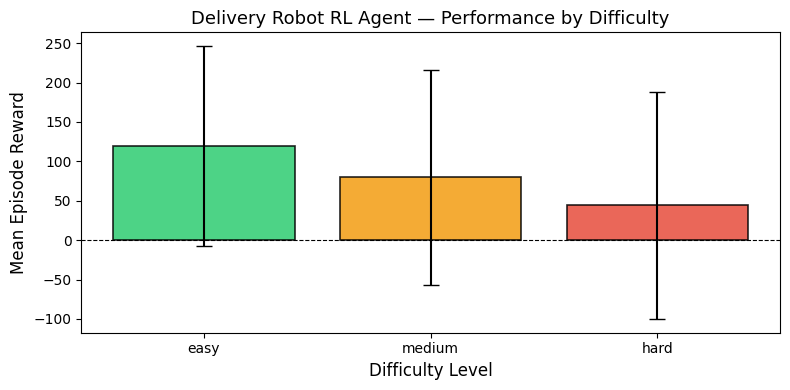

In [11]:
from stable_baselines3.common.evaluation import evaluate_policy

# Load best model
best_model = PPO.load('./models/best_model.zip', device=device)

# Evaluate on all difficulty levels
results = {}
for diff in ['easy', 'medium', 'hard']:
    test_env = DummyVecEnv([make_env(diff)])
    test_env = VecNormalize(test_env, norm_obs=True, norm_reward=False, training=False)
    mean_r, std_r = evaluate_policy(best_model, test_env, n_eval_episodes=20)
    results[diff] = (mean_r, std_r)
    print(f'{diff:8s}: Mean reward = {mean_r:.1f} ± {std_r:.1f}')

# Bar plot
fig, ax = plt.subplots(figsize=(8, 4))
diffs   = list(results.keys())
means   = [results[d][0] for d in diffs]
stds    = [results[d][1] for d in diffs]
colors  = ['#2ecc71', '#f39c12', '#e74c3c']
bars = ax.bar(diffs, means, yerr=stds, capsize=6,
              color=colors, alpha=0.85, edgecolor='k', linewidth=1.2)
ax.set_xlabel('Difficulty Level', fontsize=12)
ax.set_ylabel('Mean Episode Reward', fontsize=12)
ax.set_title('Delivery Robot RL Agent — Performance by Difficulty', fontsize=13)
ax.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.savefig('./evaluation_results.png', dpi=150)
plt.show()

Running rollout...
🗺️  Loading OSM map for مدينة السماد، طلخا …
⚠️  osmnx failed (graph_from_bbox() takes 1 positional argument but 4 positional arguments (and 2 keyword-only arguments) were given), falling back to Overpass API …
⚠️  Overpass API error: 406 Client Error: Not Acceptable for url: https://overpass-api.de/api/interpreter
   ⚠️  OSM unavailable — using cached Samaad City street template
✅ Map loaded  |  free cells: 1476


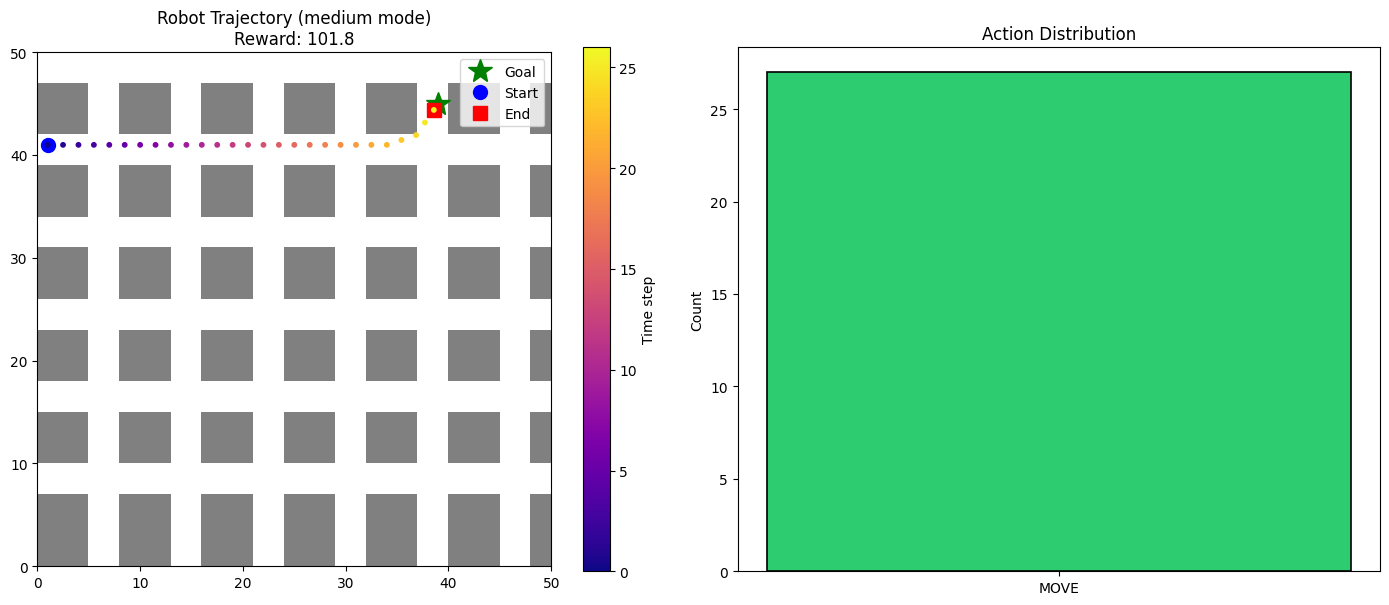

Episode reward: 101.8
Final info: {'action': 'MOVE', 'dist_to_goal': np.float32(0.7349709), 'collided': True, 'reached': np.True_, 'step': 27}


In [12]:
# ============================================================
#  Rollout visualization — watch the agent drive!
# ============================================================

def run_episode_visual(model, difficulty='medium', max_steps=200):
    env  = DeliveryRobotEnv(difficulty=difficulty)
    obs, _ = env.reset()

    history = {'pos': [], 'actions': [], 'rewards': []}
    total_reward = 0
    done = False
    step = 0

    while not done and step < max_steps:
        action, _ = model.predict(obs, deterministic=True)
        action = int(action)
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        history['pos'].append(env.robot_pos.copy())
        history['actions'].append(DeliveryRobotEnv.ACTIONS[action])
        history['rewards'].append(reward)
        total_reward += reward
        step += 1

    # Render final map with trajectory
    G = env.GRID_SIZE
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Left: trajectory map
    ax = axes[0]
    ax.imshow(env.grid, cmap='Greys', origin='lower',
              extent=[0, G, 0, G], alpha=0.5)
    traj = np.array(history['pos'])
    sc = ax.scatter(traj[:, 1], traj[:, 0],
                    c=range(len(traj)), cmap='plasma', s=10, zorder=3)
    plt.colorbar(sc, ax=ax, label='Time step')
    ax.plot(env.goal_pos[1], env.goal_pos[0], 'g*', markersize=18, label='Goal')
    ax.plot(traj[0, 1], traj[0, 0], 'bo', markersize=10, label='Start')
    ax.plot(traj[-1, 1], traj[-1, 0], 'rs', markersize=10, label='End')
    ax.set_title(f'Robot Trajectory ({difficulty} mode)\nReward: {total_reward:.1f}')
    ax.legend()

    # Right: action distribution
    from collections import Counter
    action_counts = Counter(history['actions'])
    ax2 = axes[1]
    colors_map = {'MOVE': '#2ecc71', 'STOP': '#e74c3c',
                  'WAIT': '#f39c12', 'AVOID': '#3498db'}
    acts   = list(action_counts.keys())
    counts = list(action_counts.values())
    ax2.bar(acts, counts,
            color=[colors_map.get(a, 'gray') for a in acts],
            edgecolor='k', linewidth=1.2)
    ax2.set_title('Action Distribution')
    ax2.set_ylabel('Count')

    plt.tight_layout()
    plt.savefig(f'./rollout_{difficulty}.png', dpi=150)
    plt.show()

    return total_reward, info


print('Running rollout...')
reward, info = run_episode_visual(best_model, difficulty='medium')
print(f'Episode reward: {reward:.1f}')
print(f'Final info: {info}')

## 🔄 Section 8: Curriculum Learning — Progressive Difficulty

In [13]:
def curriculum_train(total_timesteps_per_stage=150_000):
    """
    Train progressively: easy → medium → hard.
    This helps the agent learn basic navigation before dealing with
    heavy traffic.
    """
    stages = [
        ('easy',   total_timesteps_per_stage),
        ('medium', total_timesteps_per_stage),
        ('hard',   total_timesteps_per_stage),
    ]

    curr_model = None

    for stage_name, steps in stages:
        print(f'\n{'='*50}')
        print(f'  Stage: {stage_name.upper()} | {steps:,} timesteps')
        print(f'{'='*50}')

        env = DummyVecEnv([make_env(stage_name) for _ in range(4)])
        env = VecNormalize(env, norm_obs=True, norm_reward=True)

        if curr_model is None:
            curr_model = PPO(
                'MlpPolicy', env,
                policy_kwargs=policy_kwargs,
                learning_rate=3e-4,
                n_steps=512,
                batch_size=64,
                verbose=0,
                device=device
            )
        else:
            # Load weights into new environment
            curr_model.set_env(env)

        curr_model.learn(total_timesteps=steps, progress_bar=True)
        curr_model.save(f'./models/curriculum_{stage_name}')
        print(f'  ✅ Saved model for stage: {stage_name}')

    return curr_model


# Uncomment to run curriculum training:
# curriculum_model = curriculum_train(total_timesteps_per_stage=100_000)
print('Curriculum training function ready. Uncomment last line to run.')

Curriculum training function ready. Uncomment last line to run.


## 📹 Section 9: Real Camera Integration (Hardware Deployment)

In [ ]:
class RealRobotInterface:
    """
    Interface for running the trained RL policy on the real robot.

    Hardware assumed:
      - Raspberry Pi 4 / Jetson Nano
      - USB Camera or CSI Camera
      - LiDAR (RPLidar A1)
      - GPS + IMU (NEO-6M + MPU6050)
      - Arduino/ESP32 for motor control via serial

    Usage:
        interface = RealRobotInterface(model_path='./models/best_model')
        interface.run(goal_gps=(lat, lon))
    """

    SERIAL_PORT  = '/dev/ttyUSB0'
    BAUD_RATE    = 115200
    CAMERA_ID    = 0
    FRAME_W, FRAME_H = 640, 480

    def __init__(self, model_path):
        # Load trained policy
        self.model  = PPO.load(model_path)
        self.vision = VisionModule('yolov8n.pt')

        # Observation normalizer (must match training)
        try:
            from stable_baselines3.common.vec_env import VecNormalize
            # Load saved normalization stats
            self.normalizer_stats = np.load('./models/vec_normalize.pkl',
                                             allow_pickle=True)
        except:
            self.normalizer_stats = None

        print(' RealRobotInterface initialized')

    def read_camera(self, cap):
        ret, frame = cap.read()
        if not ret:
            return None, []
        frame = cv2.resize(frame, (self.FRAME_W, self.FRAME_H))
        tracked = self.vision.process_frame(frame)
        return frame, tracked

    def read_gps_imu(self):
        """Read GPS and IMU. Replace with actual sensor library calls."""
        # Example using gpsd:
        # import gpsd; gpsd.connect(); p = gpsd.get_current()
        # return np.array([p.lat, p.lon]), np.array([imu.ax, imu.ay])
        raise NotImplementedError('Connect your GPS/IMU library here.')

    def build_obs(self, robot_pos, robot_vel, goal_pos, tracked_objects, lidar_scan):
        """Build observation vector matching the training environment."""
        G = 50  # virtual grid size used during training

        goal_dir  = goal_pos - robot_pos
        goal_dist = np.linalg.norm(goal_dir) + 1e-6
        goal_dir_norm = goal_dir / goal_dist

        robot_feats = np.concatenate([
            robot_pos / G,
            goal_dir_norm,
            [goal_dist / G],
            robot_vel / 2.0
        ]).astype(np.float32)  # (7,)

        vision_feats = self.vision.extract_threat_features(
            tracked_objects, robot_pos,
            self.FRAME_W, self.FRAME_H)  # (48,)

        lidar_feats = np.array(lidar_scan[:8], dtype=np.float32)  # (8,)

        return np.concatenate([robot_feats, vision_feats, lidar_feats])

    def send_motor_command(self, serial_conn, action):
        """Send action to Arduino/ESP32 via serial.
        Protocol: single byte — 0=MOVE 1=STOP 2=WAIT 3=AVOID
        """
        if serial_conn:
            serial_conn.write(bytes([action]))

    def run(self, goal_pos, duration_sec=300):
        """Main control loop for real robot."""
        import serial

        cap = cv2.VideoCapture(self.CAMERA_ID)
        cap.set(cv2.CAP_PROP_FRAME_WIDTH,  self.FRAME_W)
        cap.set(cv2.CAP_PROP_FRAME_HEIGHT, self.FRAME_H)

        ser = serial.Serial(self.SERIAL_PORT, self.BAUD_RATE, timeout=0.1)

        robot_pos = np.array([0.0, 0.0])
        robot_vel = np.array([0.0, 0.0])
        lidar_scan = np.ones(8) * 0.5

        start = time.time()
        try:
            while time.time() - start < duration_sec:
                t0 = time.time()

                # 1. Perception
                frame, tracked = self.read_camera(cap)
                if frame is None:
                    continue

                # 2. Localisation (GPS/IMU)
                # robot_pos, robot_vel = self.read_gps_imu()

                # 3. Build observation
                obs = self.build_obs(robot_pos, robot_vel,
                                      goal_pos, tracked, lidar_scan)

                # 4. RL inference
                action, _ = self.model.predict(obs, deterministic=True)

                # 5. Execute
                self.send_motor_command(ser, int(action))

                # 6. Overlay on camera feed
                action_name = DeliveryRobotEnv.ACTIONS[int(action)]
                cv2.putText(frame, f'Action: {action_name}',
                            (10, 30), cv2.FONT_HERSHEY_SIMPLEX,
                            1.0, (0, 255, 0), 2)
                cv2.imshow('Delivery Robot — Live View', frame)

                if cv2.waitKey(1) & 0xFF == ord('q'):
                    break

                # Target 10 Hz loop
                elapsed = time.time() - t0
                if elapsed < 0.1:
                    time.sleep(0.1 - elapsed)

        finally:
            self.send_motor_command(ser, 1)  # STOP on exit
            cap.release()
            cv2.destroyAllWindows()
            ser.close()
            print(' Robot stopped safely.')


print(' RealRobotInterface class ready for hardware deployment!')
print('   To deploy: interface = RealRobotInterface("./models/best_model")')
print('              interface.run(goal_pos=np.array([40, 40]))')

✅ RealRobotInterface class ready for hardware deployment!
   To deploy: interface = RealRobotInterface("./models/best_model")
              interface.run(goal_pos=np.array([40, 40]))


## 🏁 Section 10: Summary & Next Steps

### What was built

| Module | Technology | Purpose |
|---|---|---|
| Object Detection | YOLOvn8 | Detect cars, pedestrians, obstacles |
| Object Tracking | Kalman Filter + IoU matching | Track objects across frames |
| Path Planning | A* algorithm | Global route from start to goal |
| RL Policy | PPO (Stable-Baselines3) | Learn when to MOVE/STOP/WAIT/AVOID |
| Neural Network | Attention-based feature extractor | Fuse camera + LiDAR + robot state |
| Simulation | Custom Gymnasium Env | Safe training environment |
| Hardware Bridge | RealRobotInterface | Deploy on Raspberry Pi / Jetson Nano |

### Recommended next steps

1. **Increase training time** — run 2M+ timesteps for better performance  
2. **Add stereo depth** — replace simulated LiDAR with real stereo camera depth  
3. **Add SLAM** — use ORB-SLAM3 or rtabmap for real-time mapping  
4. **Use Jetson Nano** — enables real-time YOLOv8 inference at 30 fps  
5. **Fine-tune on real data** — record sensor logs and retrain with imitation learning  
6. **Add traffic light recognition** — extend YOLO classes  
7. **Test in ROS2 simulation** (Gazebo) before physical deployment  